# 01 - Exploratory Data Analysis (EDA)

This notebook analyzes the raw `banking_finance_01.csv` portfolio to understand the distributions, identify missing data patterns, and explore the core IFRS 9 Stage 2 migration rate (~22%).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load Data
df = pd.read_csv('../data/raw/banking_finance_01.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (84098, 36)


,loan_id,assessment_date,loan_type,origination_channel,bank_region,loan_amount_gbp,outstanding_balance_gbp,original_loan_term_months,remaining_term_months,interest_rate_pct,...,pd_12m_current_pct,pd_relative_change_pct,ltv_change_pct_since_origination,is_restructured_loan,months_since_last_restructure,early_repayment_flag,current_account_debit_flag,origination_ltv_pct,months_on_book,stage_2_migration
0,LN-00000001,2022-Q4,Residential Mortgage,Mortgage Broker,Scotland,142100.0,69600.0,120,72,4.16,...,0.569,2.9,-4.7,No,0,No,No,74.0,48,0
1,LN-00000002,2023-Q3,SME Term Loan,Online / Digital,London,290600.0,92000.0,180,136,6.60,...,1.217,327.0,-999.0,No,0,No,No,-1.0,44,1
2,LN-00000003,2023-Q3,Buy-to-Let Mortgage,Branch,Midlands,159000.0,148400.0,48,22,4.96,...,1.197,384.6,-0.5,No,0,No,No,85.3,26,1
3,LN-00000004,2021-Q3,Personal Loan,Branch,North East,8500.0,6300.0,180,14,9.57,...,0.612,14.6,-999.0,No,0,No,No,-1.0,166,0
4,LN-00000005,2024-Q3,Buy-to-Let Mortgage,Mortgage Broker,London,160400.0,141400.0,240,40,3.67,...,0.140,-15.7,-3.1,No,0,Yes,No,89.7,200,0


### 1. The Target Variable: Stage 2 Migration

Overall Stage 2 Migration Rate: 21.98%


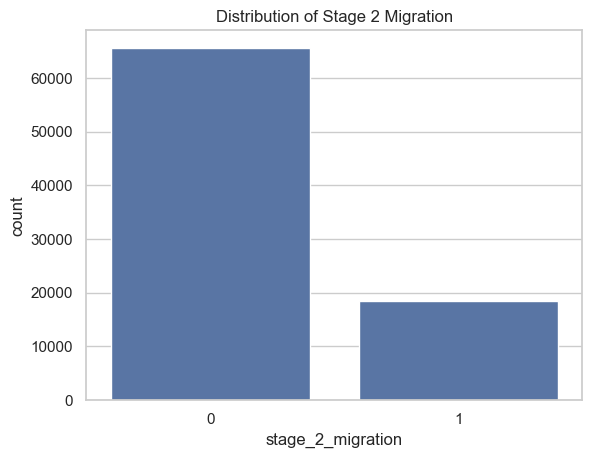

In [2]:
migration_rate = df['stage_2_migration'].mean() * 100
print(f"Overall Stage 2 Migration Rate: {migration_rate:.2f}%")

sns.countplot(data=df, x='stage_2_migration')
plt.title('Distribution of Stage 2 Migration')
plt.show()

### 2. Migration by Product Type
Unsecured products usually carry higher migration rates.

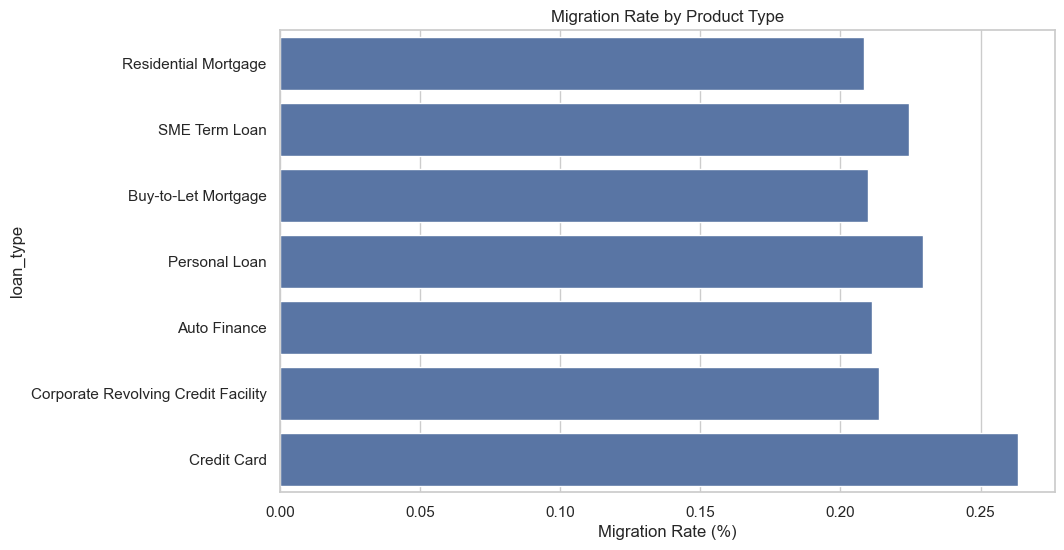

In [3]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, y='loan_type', x='stage_2_migration', errorbar=None)
plt.title('Migration Rate by Product Type')
plt.xlabel('Migration Rate (%)')
plt.show()

### 3. IFRS 9 Triggers: Days Past Due (DPD)

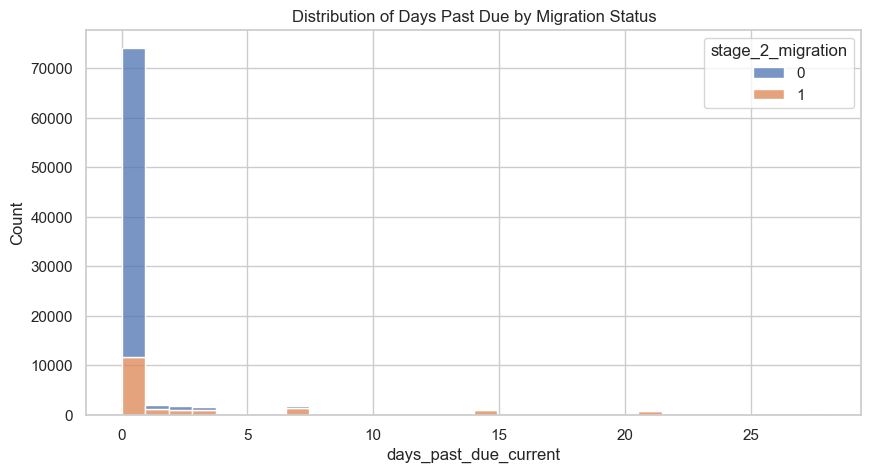

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='days_past_due_current', hue='stage_2_migration', multiple='stack', bins=30)
plt.title('Distribution of Days Past Due by Migration Status')
plt.show()